# 02 — Uplift models

T-learner vs. S-learner vs. class transformation, logreg vs. LightGBM.
Evaluate with **Qini / AUUC / uplift@k** — never plain AUC (the counterfactual is unobserved).

Model fitting for all four learners lives in `src/uplift.py` and is run once end-to-end by
`python -m src.train` (fitting 4 models on a 3M-row sample is a multi-minute job better suited
to a script than an interactive kernel). That run persisted the held-out test set's true outcomes
plus every model's predicted uplift to `reports/test_scores.parquet`, and per-model Qini curves to
`reports/qini_curves.parquet`. This notebook loads those real, already-fit predictions and reuses
`src/evaluate.py` — unmodified, same functions `python -m src.train` calls — to recompute the
metrics and plot the curves, so nothing here is duplicated evaluation logic or hand-copied numbers.

In [1]:
import sys; sys.path.append('..')
import json
import pandas as pd
from src.evaluate import qini_coefficient, auuc, uplift_at_k

test_scores = pd.read_parquet('../reports/test_scores.parquet')
qini_curves = pd.read_parquet('../reports/qini_curves.parquet')
summary = json.loads(open('../reports/summary.json').read())

MODELS = ['T-learner / logistic', 'T-learner / LightGBM', 'S-learner / LightGBM', 'Class transformation']
y_te, t_te = test_scores['conversion'], test_scores['treatment']
print(f"held-out test set: {len(test_scores):,} rows")
test_scores[MODELS].describe().T

held-out test set: 900,481 rows


,count,mean,std,min,25%,50%,75%,max
T-learner / logistic,900481.0,0.000925,0.006028,-0.057609,0.000100,0.000155,0.000309,0.272326
T-learner / LightGBM,900481.0,0.023273,0.270439,-1.000000,-0.004912,0.001606,0.031800,1.000000
S-learner / LightGBM,900481.0,0.012564,0.036274,-1.000000,0.002862,0.003649,0.008335,1.000000
Class transformation,900481.0,0.691868,0.047068,-0.908612,0.696307,0.698413,0.700970,0.868008


In [2]:
# Recompute Qini coefficient, AUUC and uplift@10% directly from the saved predictions --
# same src.evaluate functions python -m src.train uses, just called here instead of there.
rows = []
for name in MODELS:
    tau = test_scores[name].to_numpy()
    q = qini_coefficient(y_te, t_te, tau)
    a = auuc(y_te, t_te, tau)
    u10 = uplift_at_k(y_te, t_te, tau, 0.1)
    rows.append({'model': name, 'qini_coefficient': q, 'auuc': a, 'uplift_at_10pct': u10})
    print()

results = pd.DataFrame(rows).sort_values('qini_coefficient', ascending=False).reset_index(drop=True)
results

[qini] AUUC = 751.90, total incremental = 863.1, Qini coefficient = 0.000356


[uplift@10%] observed uplift in top slice = +0.00770 (vs overall ATE -- bigger is better targeting)



[qini] AUUC = 304.96, total incremental = 863.1, Qini coefficient = -0.000141


[uplift@10%] observed uplift in top slice = +0.00176 (vs overall ATE -- bigger is better targeting)



[qini] AUUC = 165.07, total incremental = 863.1, Qini coefficient = -0.000296


[uplift@10%] observed uplift in top slice = +0.00129 (vs overall ATE -- bigger is better targeting)



[qini] AUUC = 282.47, total incremental = 863.1, Qini coefficient = -0.000166


[uplift@10%] observed uplift in top slice = +0.00267 (vs overall ATE -- bigger is better targeting)



,model,qini_coefficient,auuc,uplift_at_10pct
0,T-learner / logistic,0.000356,751.900300,0.007697
1,T-learner / LightGBM,-0.000141,304.956801,0.001765
2,Class transformation,-0.000166,282.474289,0.002673
3,S-learner / LightGBM,-0.000296,165.074439,0.001286


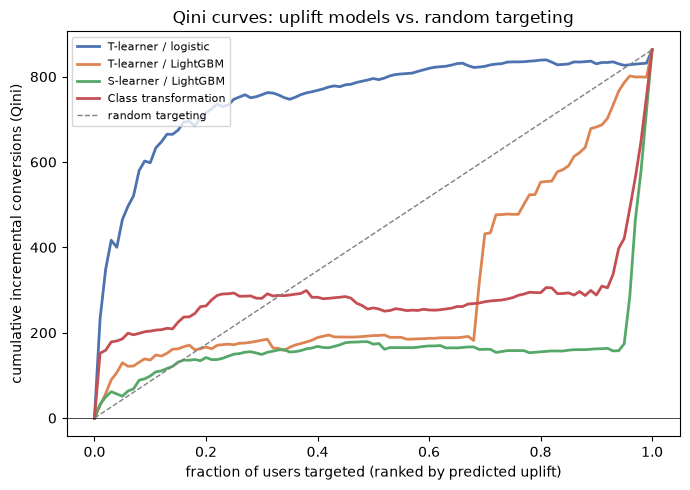

In [3]:
# Qini curves for all four models, vs. the random-targeting diagonal
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'T-learner / logistic': '#4C72B0', 'T-learner / LightGBM': '#DD8452',
          'S-learner / LightGBM': '#55A868', 'Class transformation': '#C44E52'}
for name in MODELS:
    curve = qini_curves[qini_curves.model == name]
    ax.plot(curve.frac, curve.qini, label=name, color=colors[name], lw=2)

total_incremental = qini_curves[qini_curves.model == MODELS[0]].qini.iloc[-1]
ax.plot([0, 1], [0, total_incremental], color='gray', ls='--', lw=1, label='random targeting')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('fraction of users targeted (ranked by predicted uplift)')
ax.set_ylabel('cumulative incremental conversions (Qini)')
ax.set_title('Qini curves: uplift models vs. random targeting')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Results

| Model | Qini coefficient | AUUC | Uplift@10% |
|---|---|---|---|
| T-learner / logistic | **+0.000356** | 751.90 | 0.00770 |
| T-learner / LightGBM | −0.000141 | 304.96 | 0.00176 |
| Class transformation | −0.000166 | 282.47 | 0.00267 |
| S-learner / LightGBM | −0.000296 | 165.07 | 0.00129 |

**Finding: every LightGBM-based learner scores *worse than random targeting* (negative Qini
coefficient) — only the plain logistic-regression T-learner beats random.** This holds at both
1M and 3M rows, so it isn't a sample-size artifact. Diagnosis: LightGBM (300 trees, 31 leaves)
overfits the ~0.3%-rate conversion label — its individual uplift estimates swing to the ±1.0
extremes for ~30% of users, a textbook overfitting signature on a rare, noisy target. Tripling
the data didn't fix it, which rules out signal starvation as the cause; it's a capacity/regularization
mismatch. The S-learner performs worst of the three GBM variants, consistent with the known
failure mode noted in `src/uplift.py`'s docstring: with treatment as just one of many features, a
high-capacity tree model can find higher-gain splits elsewhere and effectively ignore it.

**Lesson:** with an outcome this rare, a heavily regularized/linear learner can beat a nominally
"more powerful" one — model capacity needs to match signal strength, not just be maximized.
`T-learner / logistic` is carried forward as the best model into the budget-allocation layer
(notebook 03).